<a href="https://colab.research.google.com/github/NadimD9000-byte/Nadim-s-project/blob/main/msd_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost

In [2]:
from google.colab import files
upload =files.upload()


Saving msd_data.csv.zip to msd_data.csv.zip


In [3]:
!unzip -o msd_data.csv.zip
import pandas as pd
df = pd.read_excel('msd_risk_dataset(1).xlsx')
df.head()

Archive:  msd_data.csv.zip
  inflating: msd_risk_dataset(1).xlsx  


,Age,Gender,Height,Weight,Pain_Score,Backpack_Weight,Backpack_Height,Daily_Load_Duration,Backpack_Position,Neutral_Cervical_Curve,...,Neutral_Shoulder_Alignment,Neutral_Head_Tilt,Cervical_Deviation,Thoracic_Deviation,Lumbar_Deviation,Pelvic_Tilt_Deviation,CVA_Deviation,Shoulder_Deviation,Head_Tilt_Deviation,MSD_Risk_Level
0,18,Female,170.63,55.85,1,4.29,69.99,60,between the shoulder blades and lower back,23.67,...,0.25,0.83,1.08,0.62,0.60,0.72,2.45,0.08,0.40,Low
1,6,Male,128.00,33.17,1,3.39,43.21,45,between the shoulder blades and lower back,38.81,...,1.73,-0.81,0.92,1.67,1.20,0.43,1.80,0.51,0.39,High
2,18,Female,176.73,62.51,3,4.12,46.59,15,on the buttocks or significantly low,28.27,...,0.16,-0.64,3.94,0.11,3.84,0.23,2.31,0.61,0.04,Low
3,11,Female,145.45,39.39,0,6.26,44.68,75,slightly lower on the back,26.32,...,-0.38,-1.23,4.16,0.50,0.15,1.01,2.59,0.50,1.09,High
4,12,Male,145.61,43.54,1,6.62,39.14,60,slightly lower on the back,29.05,...,1.29,-0.51,3.59,5.76,4.71,0.82,3.99,1.63,0.07,Medium


In [4]:
print("shape:",df.shape)
print("\ncolumns:")
print (df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)


shape: (21652, 24)

columns:
Index(['Age', 'Gender', 'Height', 'Weight', 'Pain_Score', 'Backpack_Weight',
       'Backpack_Height', 'Daily_Load_Duration', 'Backpack_Position',
       'Neutral_Cervical_Curve', 'Neutral_Thoracic_Curve',
       'Neutral_Lumbar_Curve', 'Neutral_Pelvic_Tilt', 'Neutral_CVA',
       'Neutral_Shoulder_Alignment', 'Neutral_Head_Tilt', 'Cervical_Deviation',
       'Thoracic_Deviation', 'Lumbar_Deviation', 'Pelvic_Tilt_Deviation',
       'CVA_Deviation', 'Shoulder_Deviation', 'Head_Tilt_Deviation',
       'MSD_Risk_Level'],
      dtype='object')

Missing values:
Age                           0
Gender                        0
Height                        0
Weight                        0
Pain_Score                    0
Backpack_Weight               0
Backpack_Height               0
Daily_Load_Duration           0
Backpack_Position             0
Neutral_Cervical_Curve        0
Neutral_Thoracic_Curve        0
Neutral_Lumbar_Curve          0
Neutral_Pelvic_Tilt     

In [5]:
print(df['MSD_Risk_Level'].value_counts( ))

MSD_Risk_Level
Low       8745
Medium    6469
High      6438
Name: count, dtype: int64


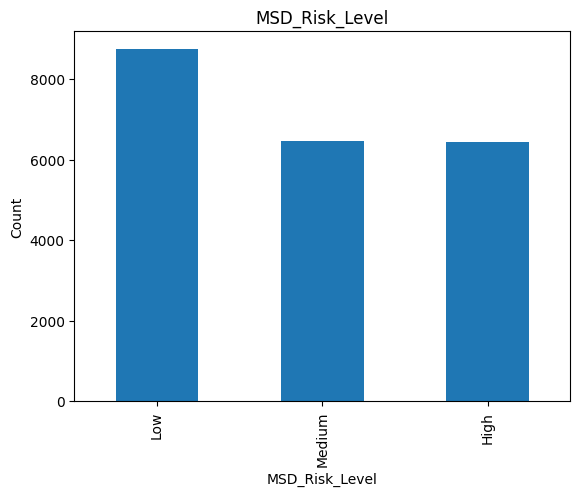

In [6]:
import matplotlib.pyplot as plt
df['MSD_Risk_Level'].value_counts().plot(kind='bar')
plt.title('MSD_Risk_Level')
plt.xlabel('MSD_Risk_Level')
plt.ylabel('Count')
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['MSD_Risk_Level'] = le.fit_transform(df['MSD_Risk_Level'])
print(le.classes_)

['High' 'Low' 'Medium']


In [8]:
X = df.drop('MSD_Risk_Level',axis=1)
y = df['MSD_Risk_Level']

In [9]:
X = pd.get_dummies(X,drop_first=True)
print(X.shape)

(21652, 24)


In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape,X_test.shape)

(17321, 24) (4331, 24)


In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    colsample_bytree=0.8,
    min_child_weight=3,
    subsample=0.8,
    reg_alpha=0.01,
    reg_lambda=2,
    random_state=42)
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=3, ...)

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import f1_score
print("weighted f1:",f1_score(y_test,y_pred,average = 'weighted'))
print("macro f1:",f1_score(y_test,y_pred,average = 'macro'))

weighted f1: 0.900776209231559
macro f1: 0.8969571532663267


In [15]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9004848764719464


In [16]:
train_pred = model.predict(X_train)
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train,train_pred)
test_acc = accuracy_score(y_test,y_pred)
print("Train Accuracy:",accuracy_score(y_train,train_pred))
print("Test Accuracy:",accuracy_score(y_test,y_pred))

Train Accuracy: 0.9505802205415391
Test Accuracy: 0.9004848764719464


In [17]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,X,y,cv=5,scoring='accuracy')
print("Cross Validation Scores:",scores)
print("Mean Cross Validation Score:",scores.mean())
print("std:",scores.std())

Cross Validation Scores: [0.89679058 0.8960979  0.89722864 0.89769053 0.89376443]
Mean Cross Validation Score: 0.896314416236563
std: 0.0013788047319824638


In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92      1288
           1       0.93      0.94      0.93      1749
           2       0.83      0.85      0.84      1294

    accuracy                           0.90      4331
   macro avg       0.90      0.90      0.90      4331
weighted avg       0.90      0.90      0.90      4331



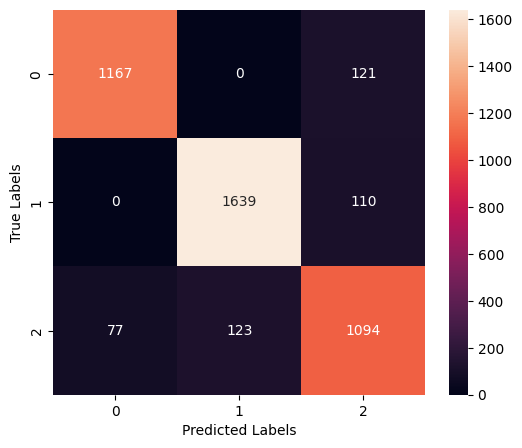

[[1167    0  121]
 [   0 1639  110]
 [  77  123 1094]]


In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
print(cm)

In [20]:
from sklearn.metrics import roc_curve,auc,roc_auc_score
y_pred_prob = model.predict_proba(X_test)
auc = roc_auc_score(y_test,y_pred_prob,multi_class='ovr',average='weighted')
print("Weighted ROC-AUC:",auc)

Weighted ROC-AUC: 0.9816667799105652


<Figure size 1000x600 with 0 Axes>

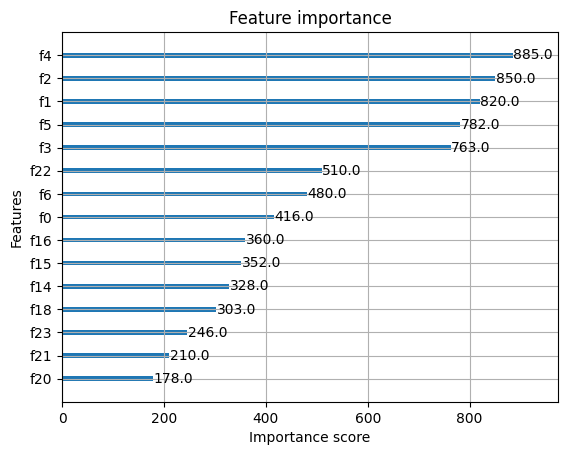

<Figure size 1000x600 with 0 Axes>

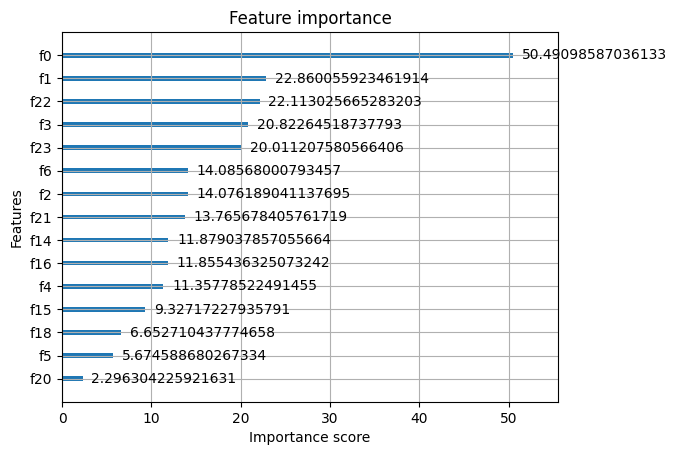

In [21]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plot_importance(model,max_num_features=15)
plt.show()
plt.figure(figsize=(10,6))
plot_importance(model,max_num_features=15,importance_type='gain')
plt.show()

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
models={"Logistic Regression":Pipeline([('scaler',StandardScaler()),('ir',LogisticRegression(max_iter=5000,random_state=42))
]),
      "Decision Tree":DecisionTreeClassifier(random_state=42),
        "Random Forest":RandomForestClassifier(random_state=42),
        "SVM":Pipeline([
            ('scaler',StandardScaler()),
            ('svm',SVC())
        ]),
        "XGBoost":model}
results=[]
for name,model_obj in models.items():
  if name!="XGBoost":
    model_obj.fit(X_train,y_train)
    y_pred=model_obj.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    results.append([name,acc])
  else:
    y_pred_xgb = model.predict(X_test)
    acc_xgb = accuracy_score(y_test,y_pred_xgb)
    results.append([name, acc_xgb])

for r in results:
  print(r)

['Logistic Regression', 0.788039713691988]
['Decision Tree', 0.7610251673978295]
['Random Forest', 0.8335257446317248]
['SVM', 0.8240591087508659]
['XGBoost', 0.9004848764719464]


In [23]:
!pip install shap

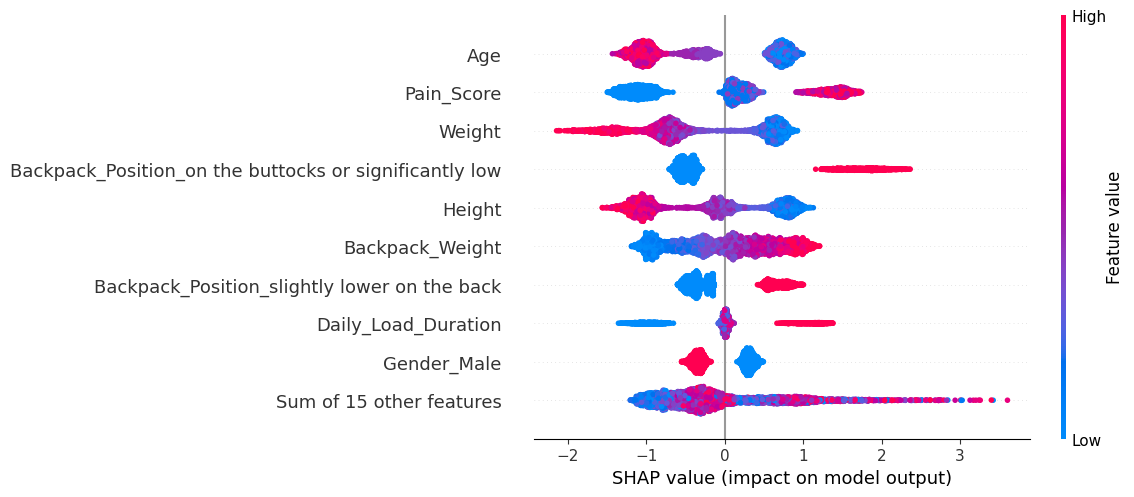

In [24]:
import shap
import pandas as pd

explainer = shap.TreeExplainer(model)
# Convert X_test (numpy array) back to a DataFrame with feature names
X_test_df = pd.DataFrame(X_test, columns=X.columns)
# Get shap values, which will now have feature names
shap_values = explainer(X_test_df)
# Assuming you want to plot SHAP values for the first class (index 0)
# You can choose a different index depending on which class you are interested in
shap.plots.beeswarm(shap_values[:, :, 0])